In [21]:
import torch
import torch.nn as nn
import torch.optim as opt

import h_util

torch.manual_seed(42)

In [22]:
d = torch.tensor([[1.0],[2.0],[3.0],[4.0]], dtype=torch.float32)
t = torch.tensor([[6.96],[12.11],[16.77],[22.21]], dtype=torch.float32)

In [23]:
model = nn.Sequential(nn.Linear(1,1))

In [24]:
loss_funck = nn.MSELoss()
optimiser = opt.SGD(model.parameters(), lr=0.01)

In [25]:
for epoch in range(500):
    optimiser.zero_grad()
    out = model(d)
    loss = loss_funck(out,t)
    loss.backward()
    optimiser.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 0.03944866359233856
Epoch 100: Loss = 0.03581171855330467
Epoch 150: Loss = 0.03311903774738312
Epoch 200: Loss = 0.03112369030714035
Epoch 250: Loss = 0.02964562550187111
Epoch 300: Loss = 0.02855011820793152
Epoch 350: Loss = 0.0277385413646698
Epoch 400: Loss = 0.027137158438563347
Epoch 450: Loss = 0.026691768318414688
Epoch 500: Loss = 0.026361485943198204


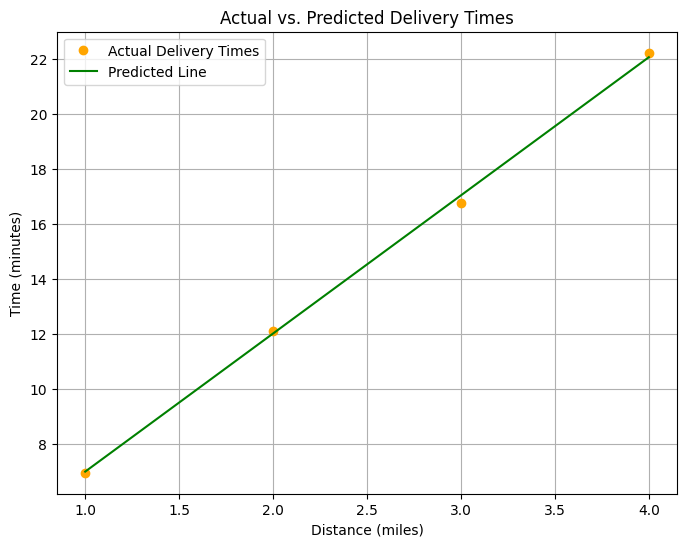

In [26]:
h_util.plot_results(model,d,t)

In [27]:
d_pred = 7.0

In [28]:
with torch.no_grad():
    new_d = torch.tensor([[d_pred]], dtype=torch.float32)
    
    pred_t = model(new_d)
    
    print(f"Predicted time for a distance of {new_d} is {pred_t.item():.1f} minutes")
    
    if pred_t.item() > 30:
        print("\nDecision : Do NOT take this JOB")
    else:
        print("\nDecision : Take the JOB")

Predicted time for a distance of tensor([[7.]]) is 37.1 minutes

Decision : Do NOT take this JOB


In [29]:
layer = model[0]

w = layer.weight.data.numpy()
b = layer.bias.data.numpy()

print(f"Weight : {w}")
print(f"Bias : {b}")

Weight : [[5.015503]]
Bias : [1.9849643]
